## Multiscale Truchet Tiles

This notebook generates multiscale Truchet tiles, which are a type of decorative tile pattern (see README).
The patterns are created using a recursive algorithm that allows for different levels of detail and complexity.

The N6 tiles refer to a specific set of Truchet tiles that are based on a grid of 6x6 sub-tiles.

_Copyright Ned Batchelder 2022_

In [1]:
from truchet_viewer import multiscale_truchet, show_tiles
from truchet_viewer.carlson import carlson_tiles
from truchet_viewer.helpers import make_bgfg
from truchet_viewer.n6 import n6_circles, n6_connected, n6_filled, n6_lattice, n6_strokes, n6_tiles, n6_weird
from truchet_viewer.tiler import value_chart

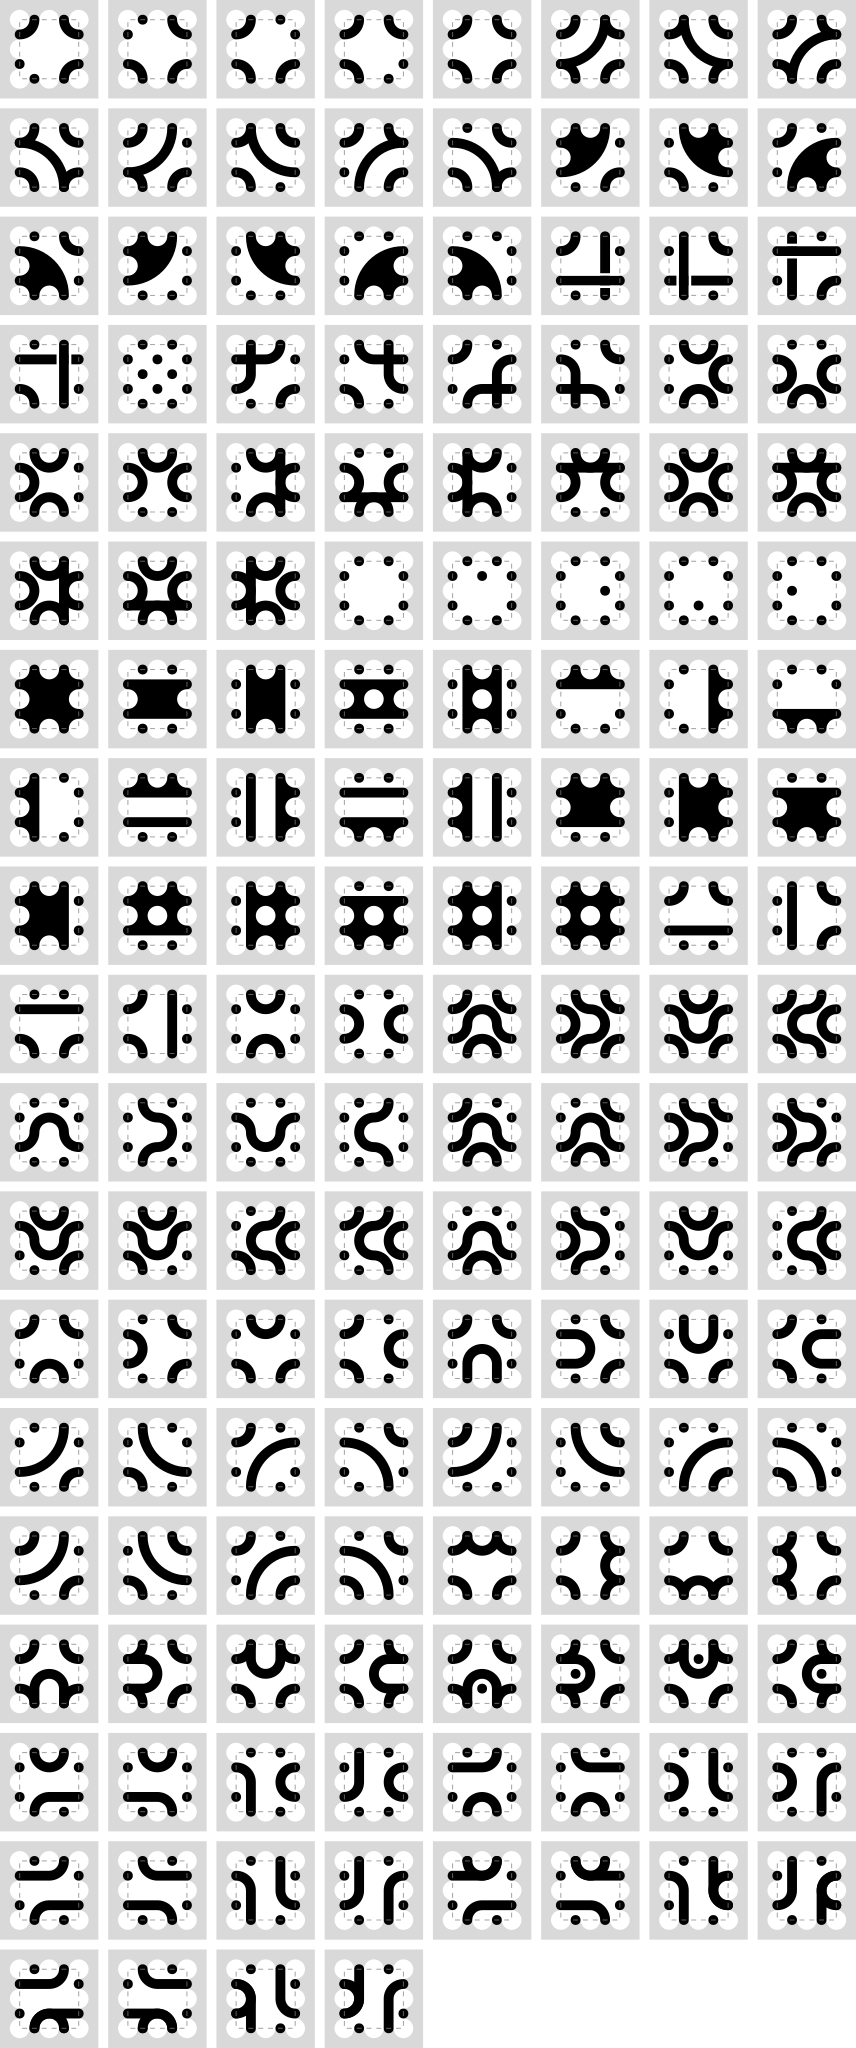

In [2]:
show_tiles(n6_tiles)

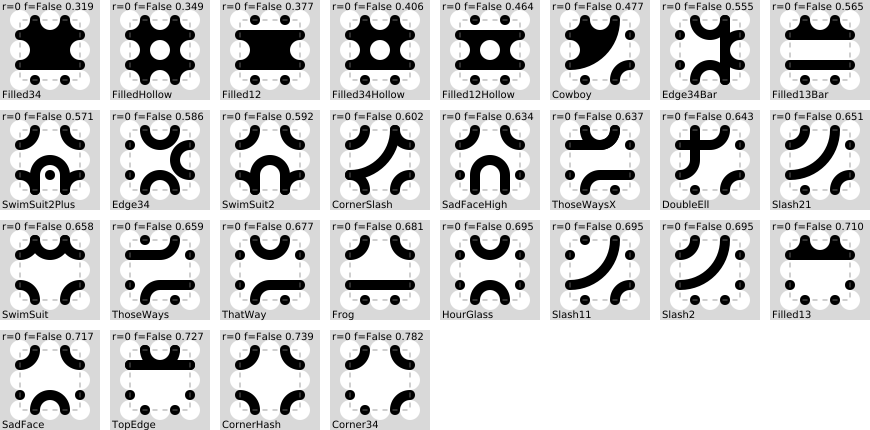

In [3]:
show_tiles(n6_circles, with_value=True, with_name=True, only_one=True, size=100, width=900)

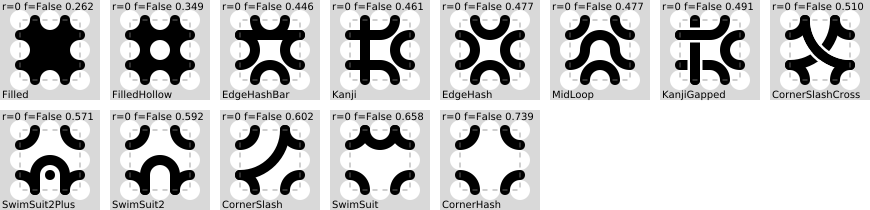

In [4]:
show_tiles(n6_connected, with_value=True, with_name=True, only_one=True, size=100, width=900)

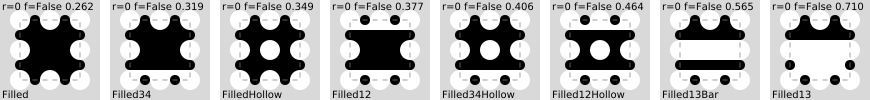

In [5]:
show_tiles(n6_filled, with_value=True, with_name=True, only_one=True, size=100, width=1200)

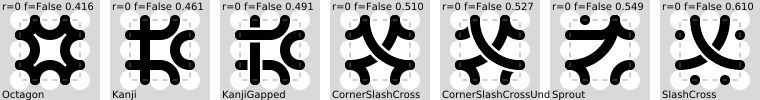

In [6]:
show_tiles(n6_weird, with_value=True, with_name=True, only_one=True, size=100, width=1200)

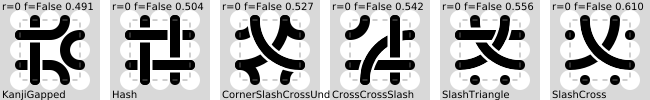

In [7]:
show_tiles(n6_lattice, with_value=True, with_name=True, only_one=True, size=100, width=1200)

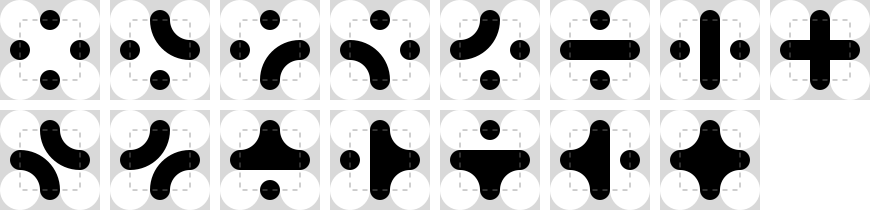

In [8]:
show_tiles(carlson_tiles)

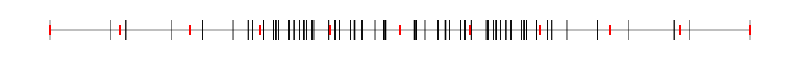

In [9]:
value_chart(n6_tiles, inverted=True)

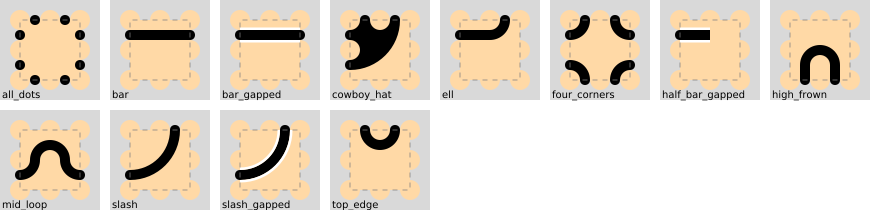

In [10]:
show_tiles(n6_strokes, with_name=True)

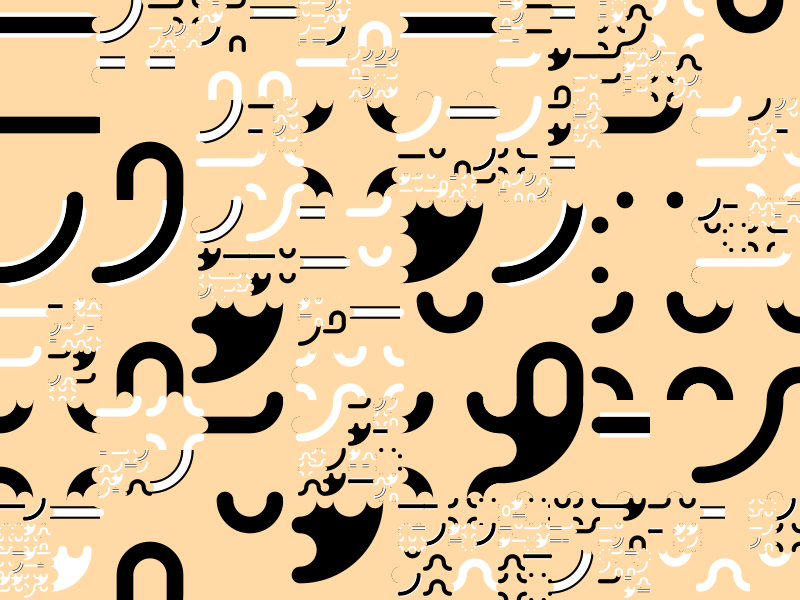

In [11]:
multiscale_truchet(tiles=n6_strokes, width=800, height=600, tilew=100, nlayers=4, chance=0.45, grid=False, seed=18)

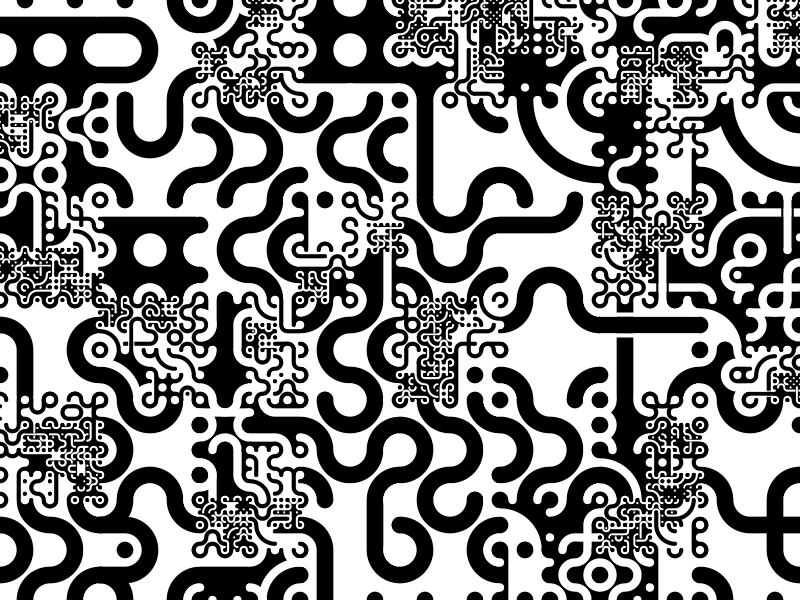

In [12]:
multiscale_truchet(tiles=n6_tiles, width=800, height=600, tilew=100, nlayers=4, chance=0.45, grid=False, seed=18)

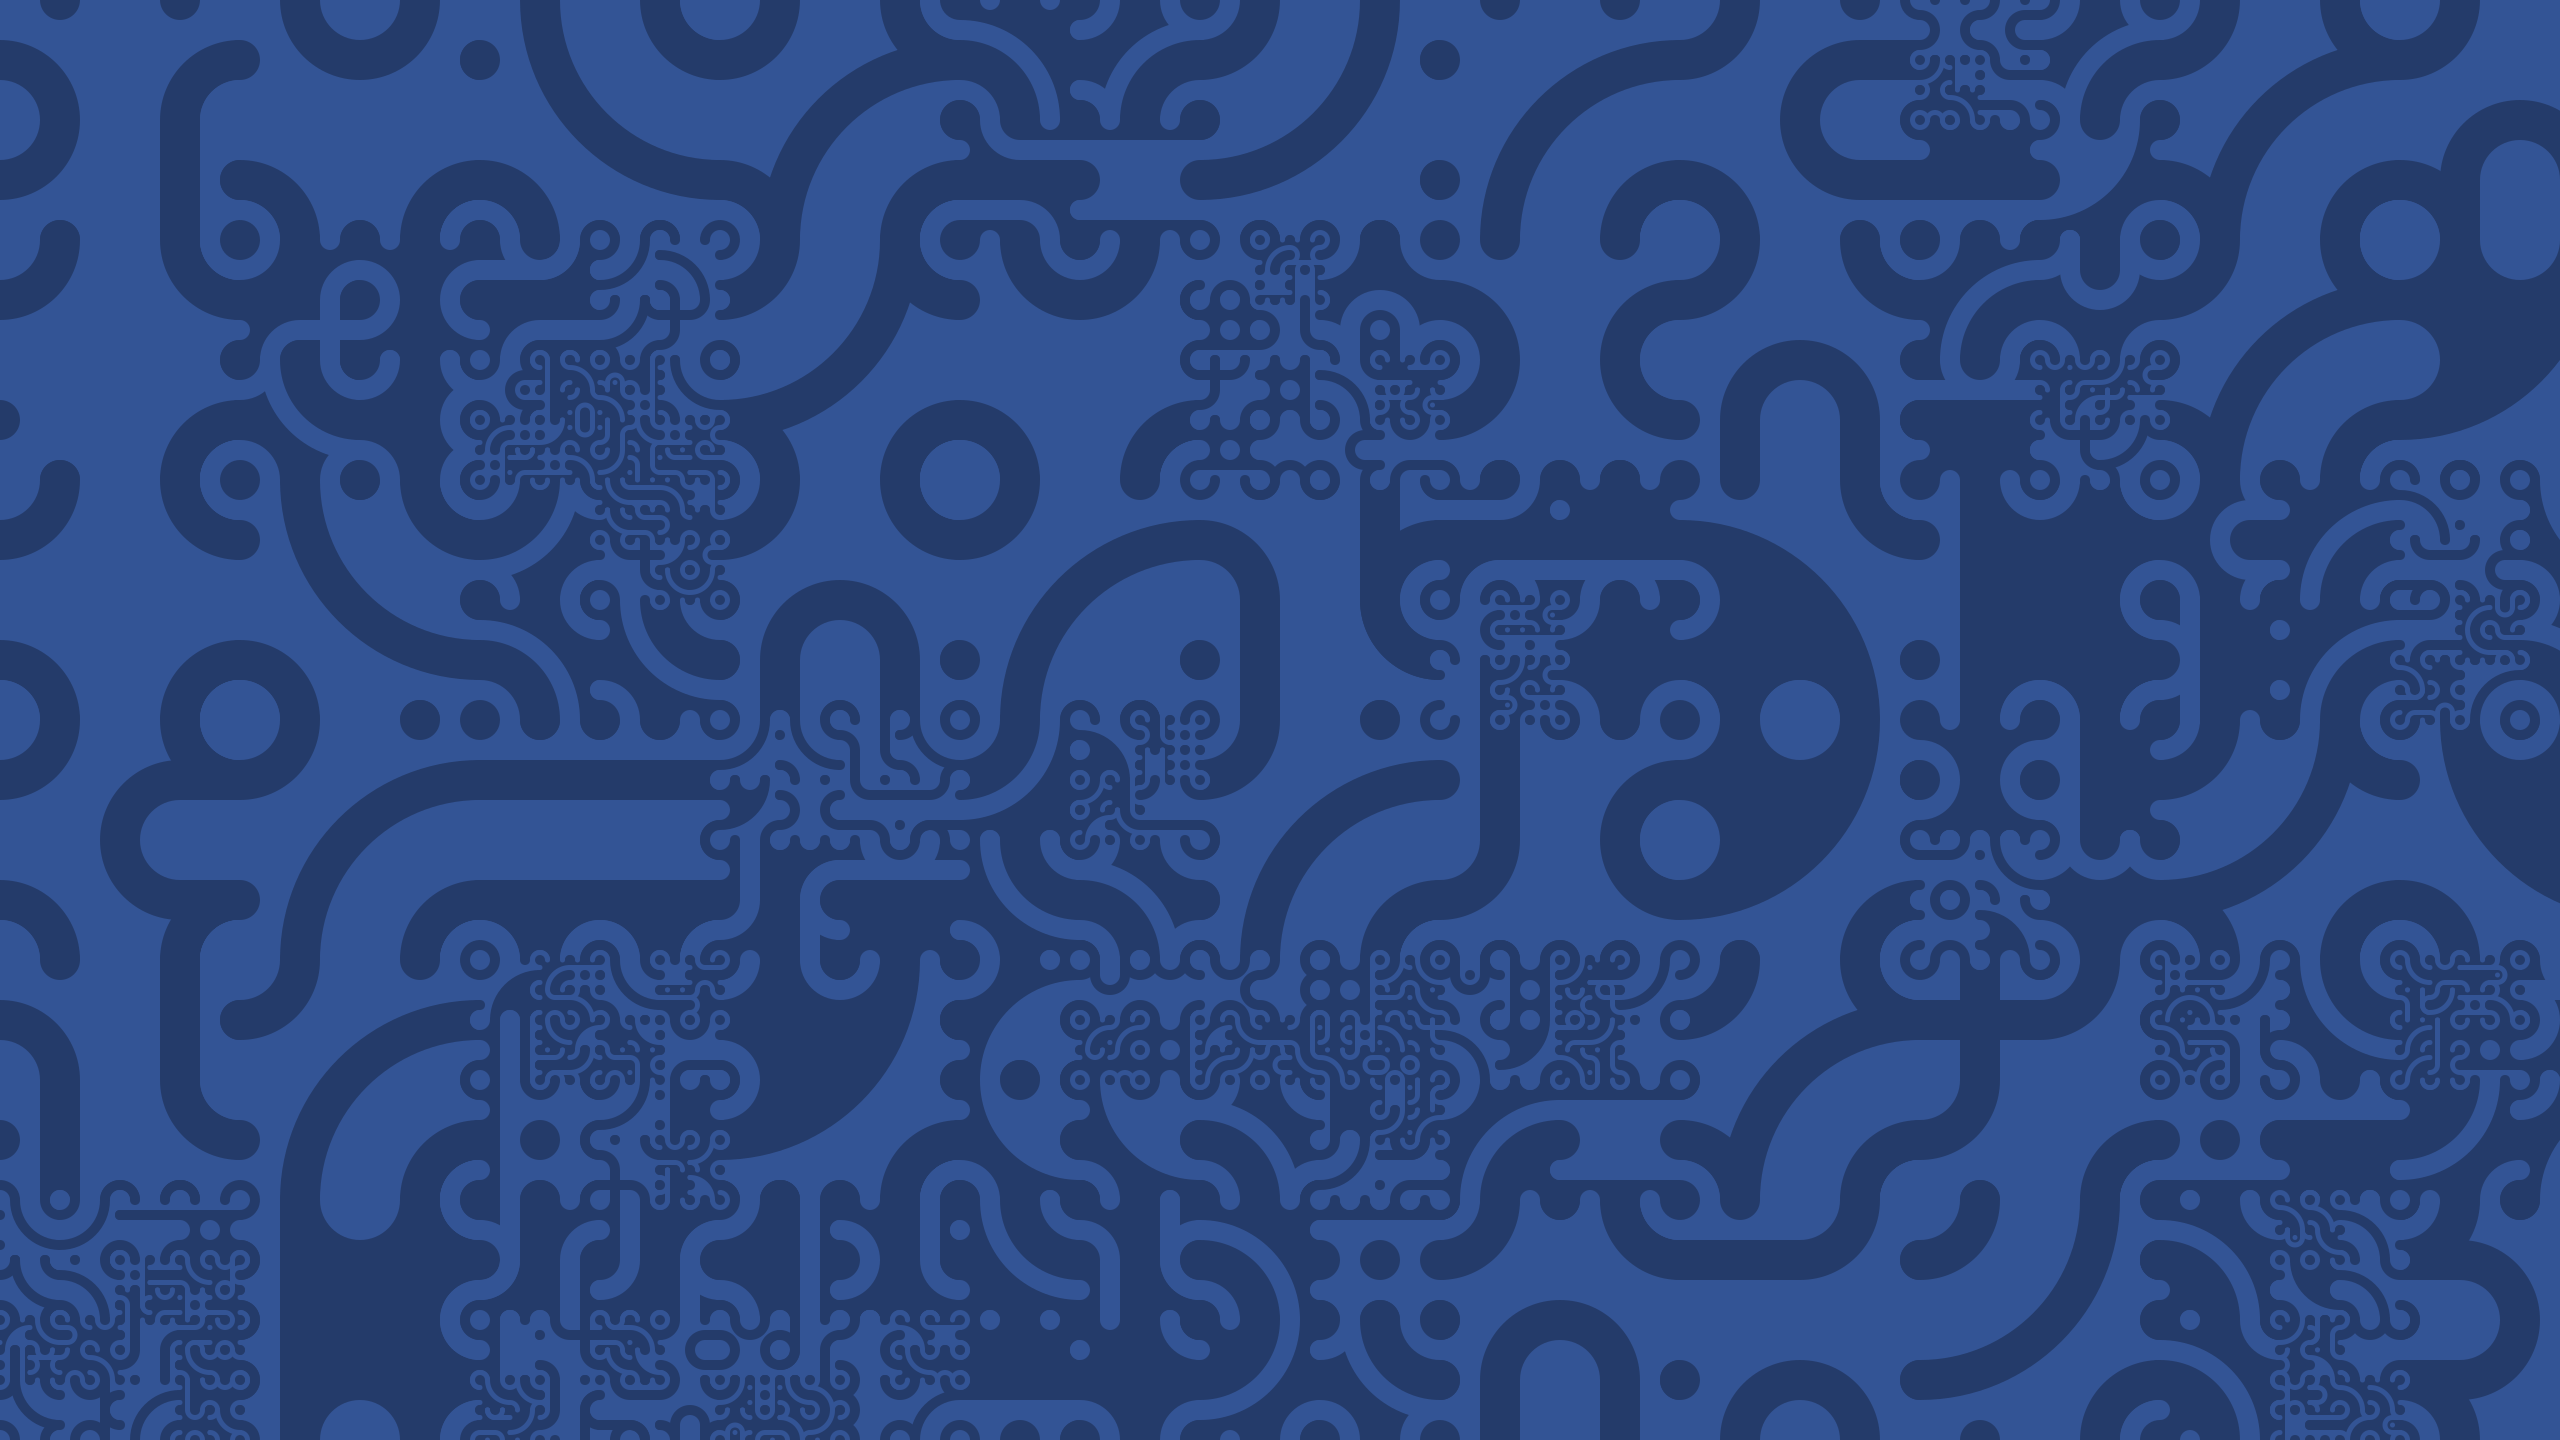

In [13]:
multiscale_truchet(
    tiles=n6_circles,
    width=2560,
    height=1440,
    tilew=240,
    nlayers=4,
    chance=0.4,
    bg='#335495',
    fg='#243b6a',
    format='png',
    # output='~/wallpaper/tru6.png',
)

## Variations

Here we explore various ways to change the distributions of the sublayers by introducing "chance" functions.

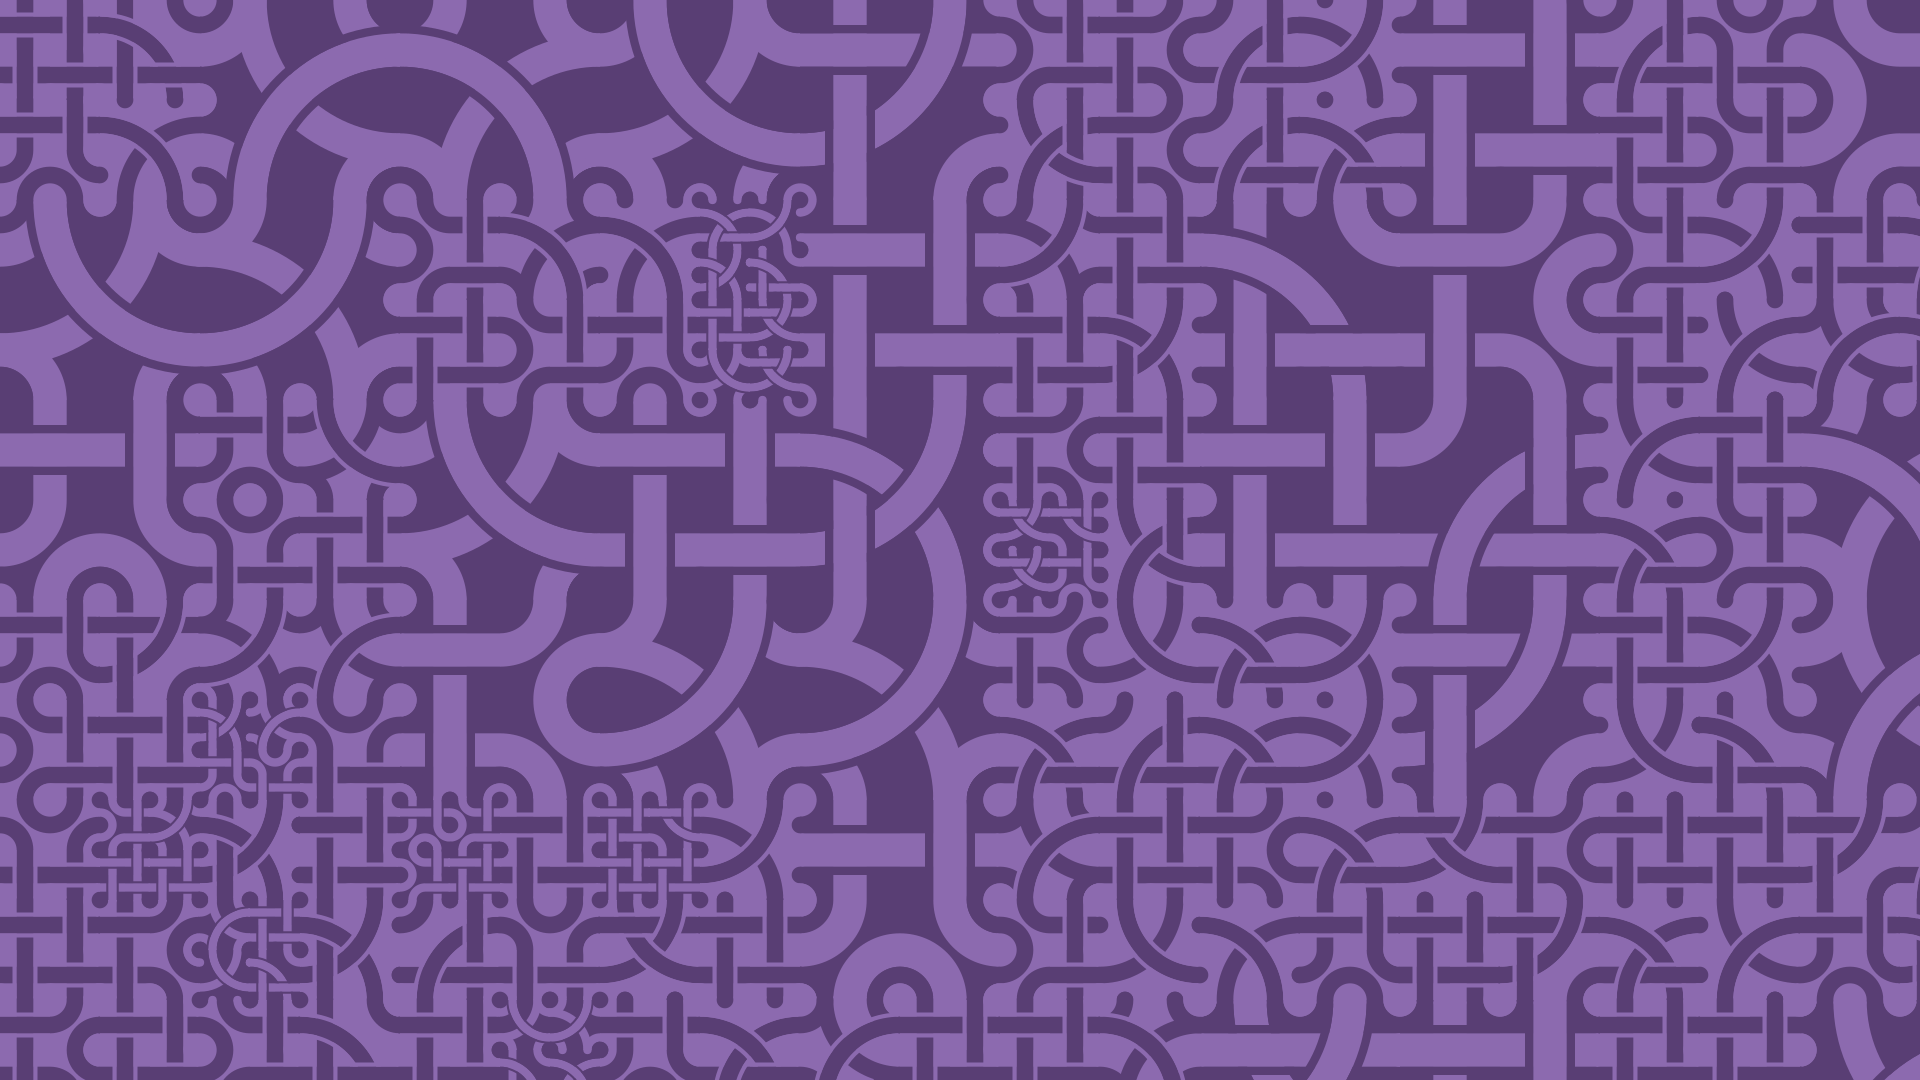

In [14]:
multiscale_truchet(
    tiles=n6_lattice,
    width=1920,
    height=1080,
    tilew=400,
    nlayers=5,
    padding=0,
    chance=(lambda x, y, size, ilayer: [0.9, 0.5, 0.1, 0.1][ilayer]),
    seed=102,
    **make_bgfg((0.75), (0.55, 0.35), (0.3)),
    format='png',
)

In [15]:
for seed in range(100):
    multiscale_truchet(
        tiles=n6_lattice,
        width=1920,
        height=1080,
        tilew=400,
        nlayers=3,
        chance=(lambda x, y, size, ilayer: [0.9, 0.5][ilayer]),
        seed=seed,
        **make_bgfg((0.35), (0.50, 0.45), (0.3)),
        format='png',
        output=f'~/wallpaper/dwn/zoomy/truchet_{seed:02d}.png',
    )

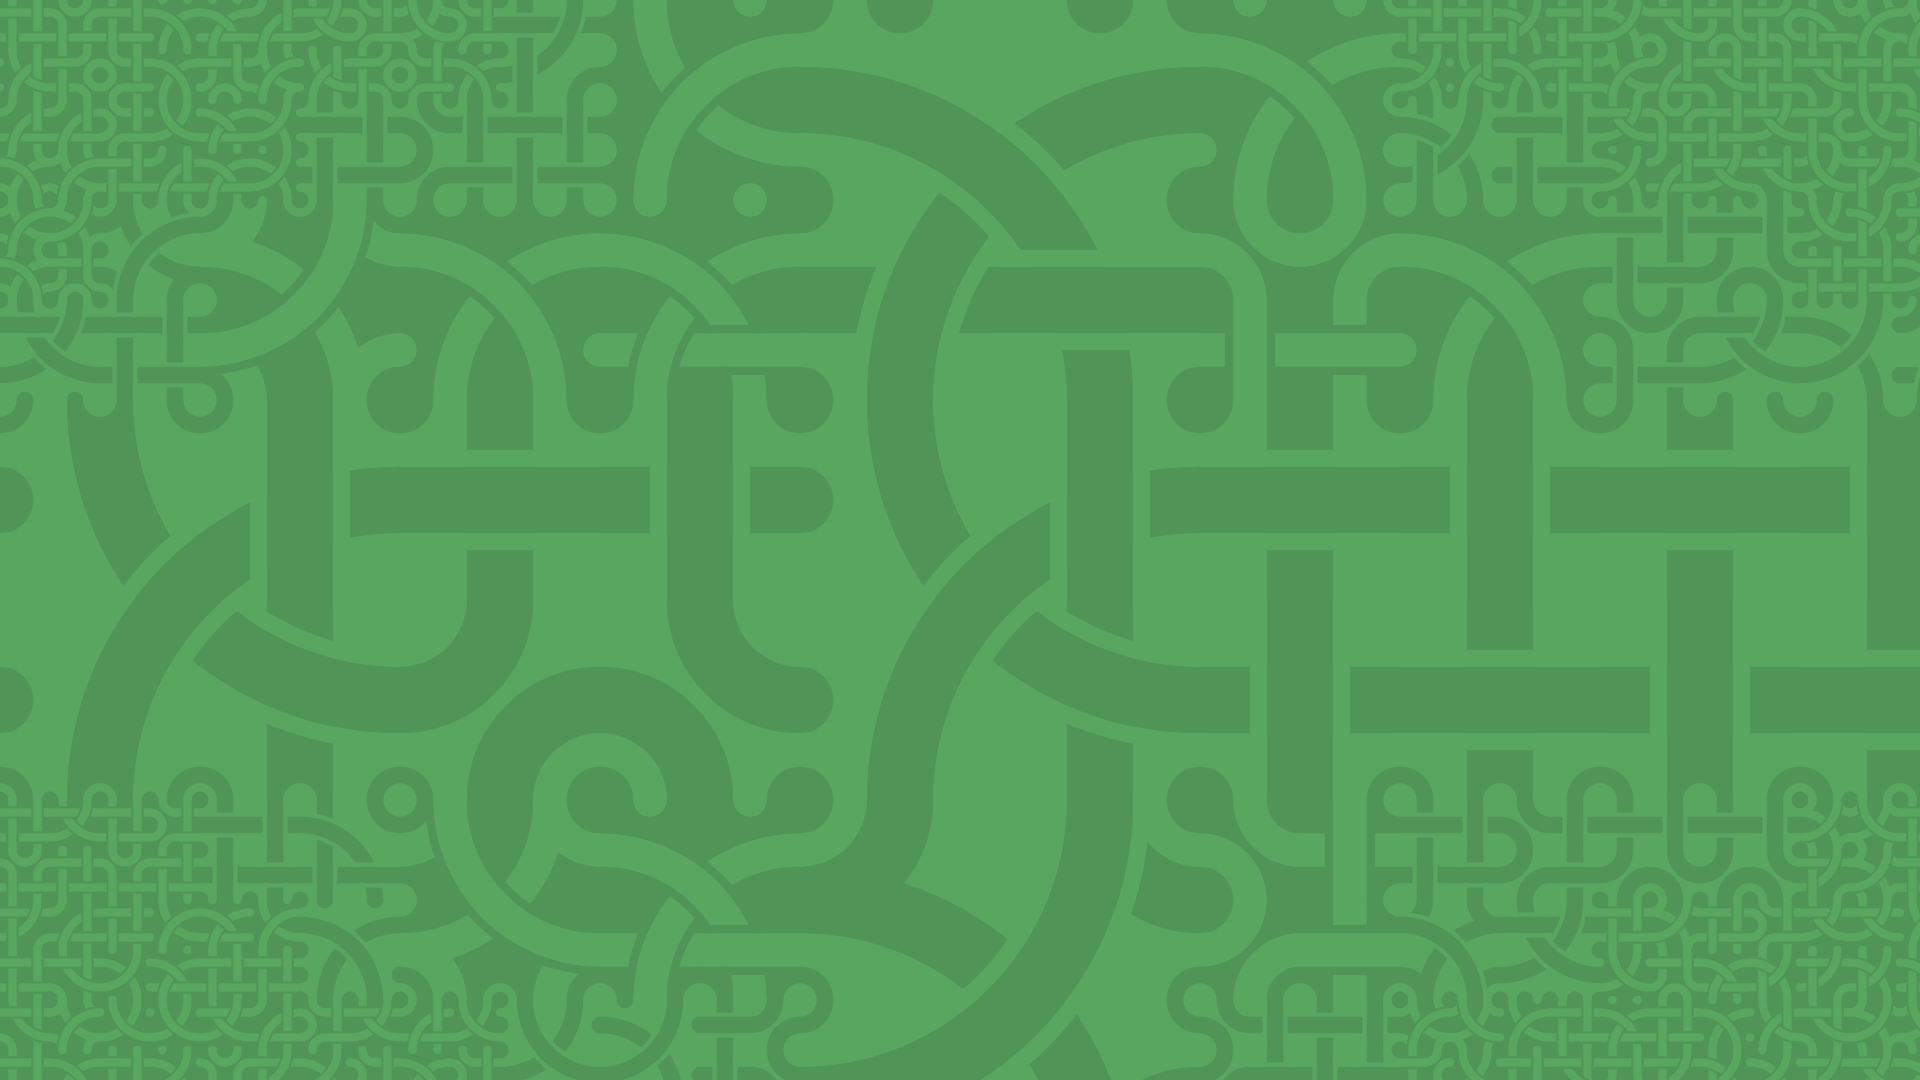

In [16]:
from math import sqrt


def ring_chance(x, y, size, ilayer):
    dist_from_center = abs(x - 0.5) + abs(y - 0.5)
    thresh = [0.5, 0.6, 0.7, 0.8][ilayer]
    return float(dist_from_center > thresh)


multiscale_truchet(
    tiles=n6_lattice,
    width=1920,
    height=1080,
    tilew=400,
    padding=0,
    nlayers=4,
    chance=ring_chance,
    seed=102,
    **make_bgfg((0.35), (0.50, 0.45), (0.3)),
    format='png',
    # output="/dwn/zoomarch_truchet.png",
)

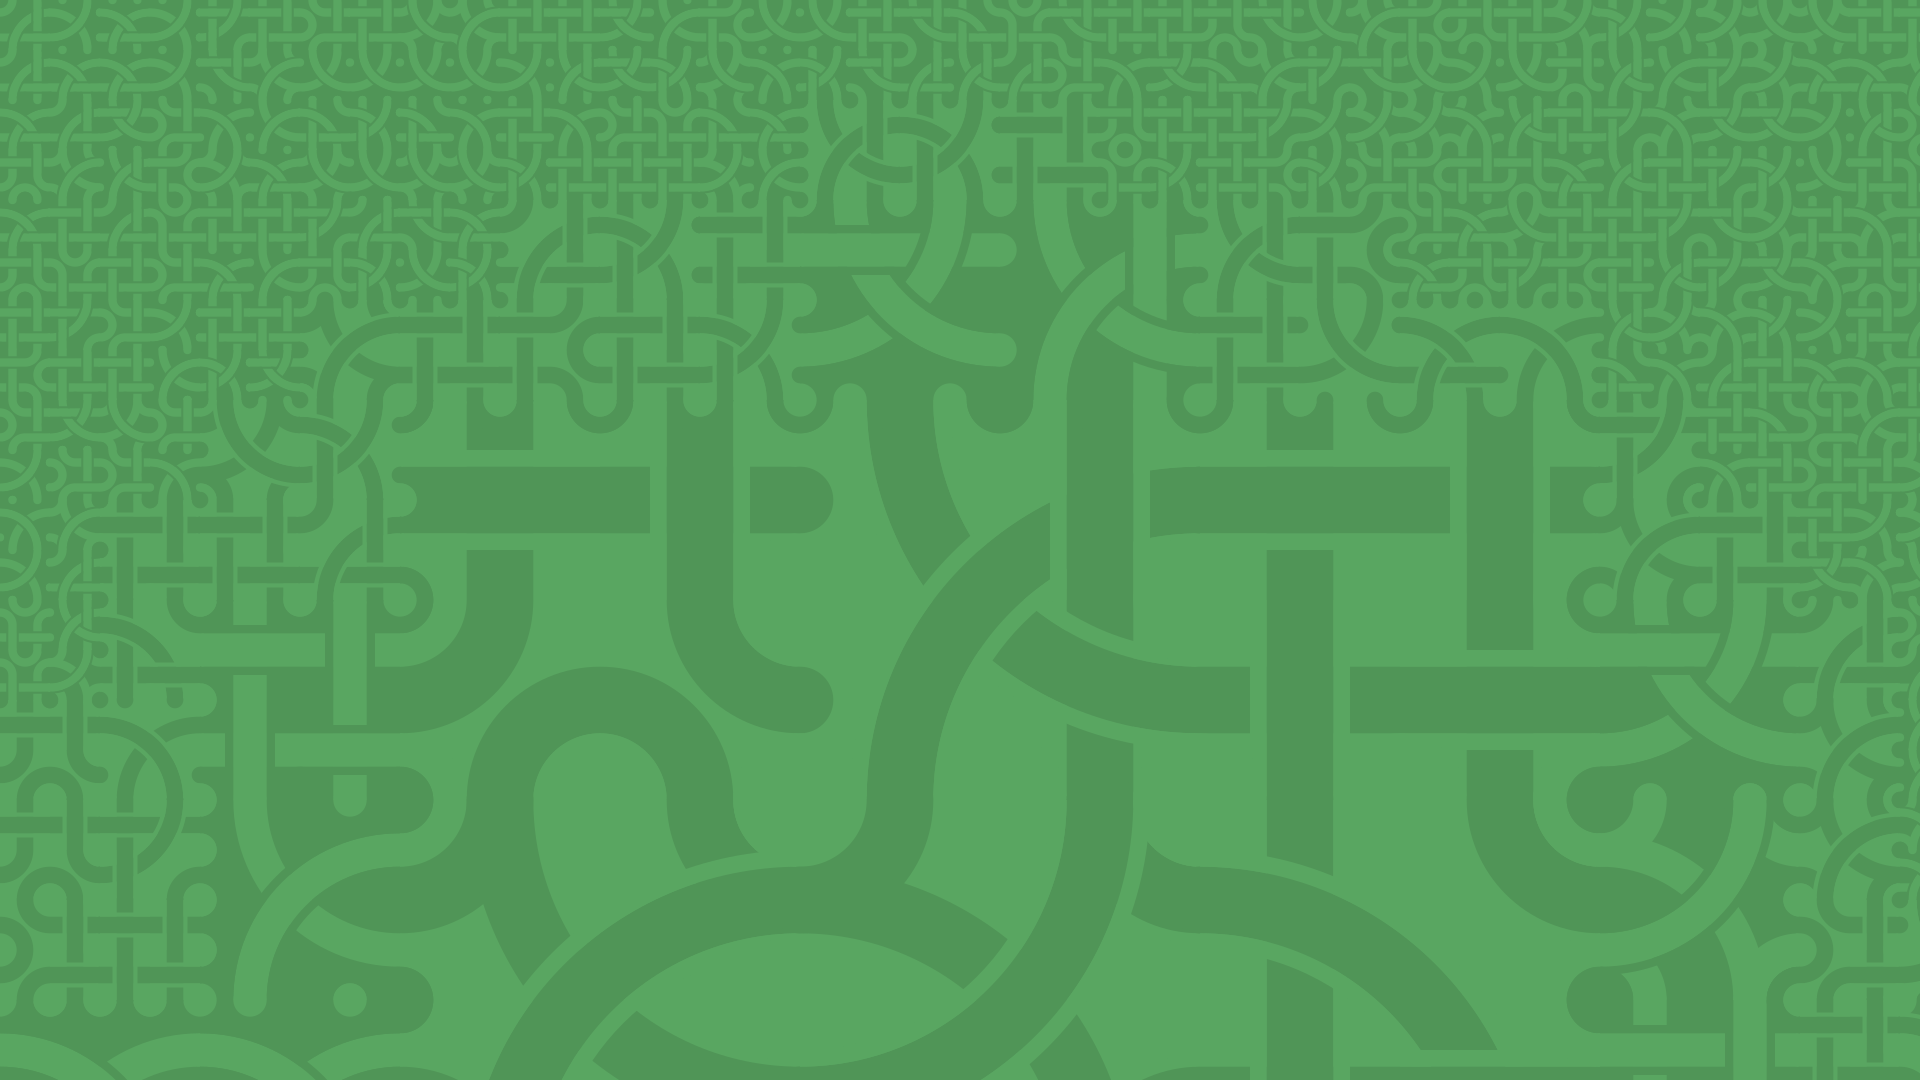

In [17]:
def arch_distance(x, y):
    return sqrt(((x - 0.5) / 0.75) ** 2 + ((y - 1) / 1.25) ** 2)


def arch_chance(x, y, size, ilayer):
    thresh = [0.5, 0.6, 0.7, 0.8][ilayer]
    return float(arch_distance(x, y) > thresh)


multiscale_truchet(
    tiles=n6_lattice,
    width=1920,
    height=1080,
    tilew=400,
    nlayers=4,
    chance=arch_chance,
    seed=102,
    **make_bgfg((0.35), (0.50, 0.45), (0.3)),
    format='png',
    # output="/dwn/zoomarch_truchet.png",
)

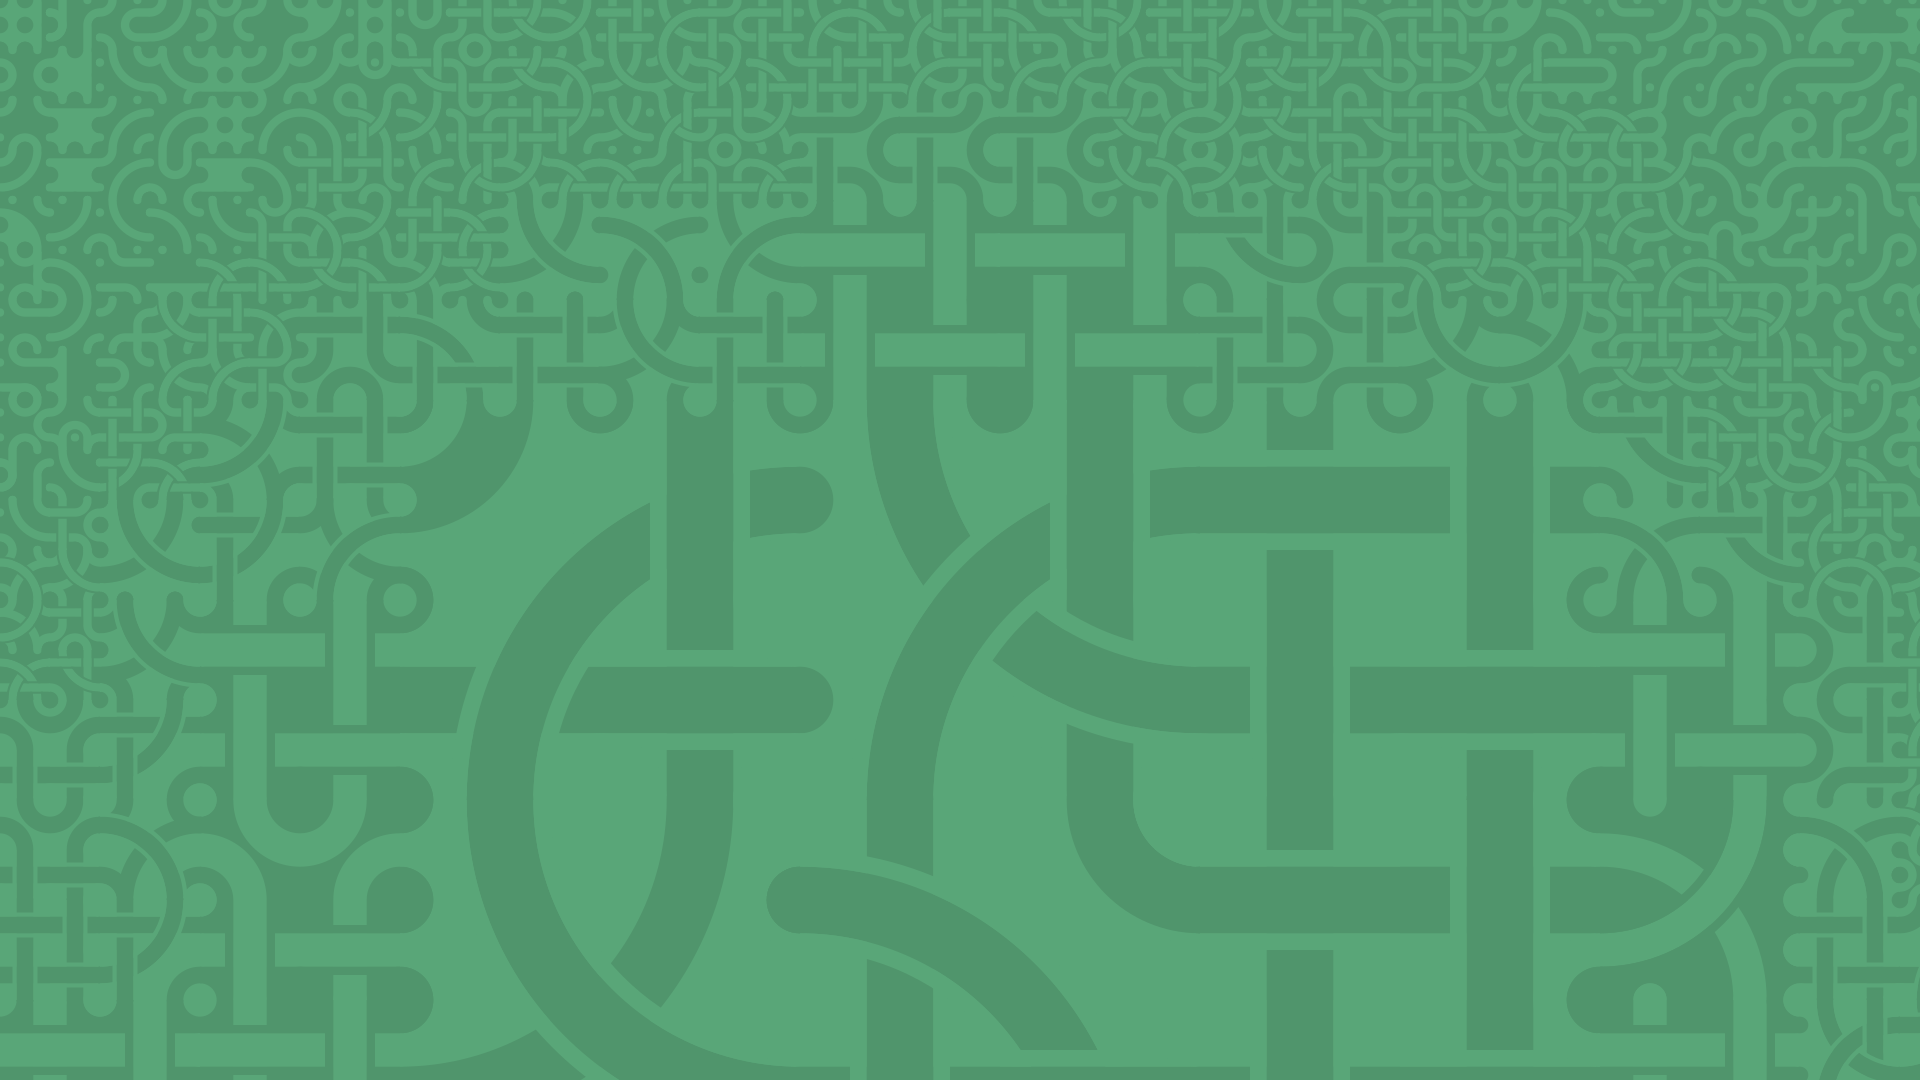

In [18]:
import random


def tile_chooser(ux, uy, uw, ilayer):
    dist = arch_distance(ux, uy)
    tiles = n6_lattice if dist < 0.88 else n6_circles
    return random.choice(tiles)


multiscale_truchet(
    tile_chooser=tile_chooser,
    width=1920,
    height=1080,
    tilew=400,
    nlayers=4,
    chance=arch_chance,
    **make_bgfg((0.40), (0.50, 0.45), (0.3)),
    seed=18,
    format='png',
    # output='~/wallpaper/dwn/zoom.png',
)